# MODULE 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvals, inv

In [ ]:
def validate_covariance(Sigma, tol=1e-8):
    # symmetric
    if not np.allclose(Sigma, Sigma.T, atol=tol):
        raise ValueError("Covariance matrix is not symmetric")

    # diagonal = 1
    if not np.allclose(np.diag(Sigma), 1.0, atol=tol):
        raise ValueError("Diagonal entries of covariance must be 1")

    # PSD
    eigvals = np.linalg.eigvalsh(Sigma)
    if np.any(eigvals < -tol):
        raise ValueError("Covariance matrix is not PSD")


In [ ]:
def generate_data(n, cov, w, noise_type="gaussian", noise_param=0.1, seed=0):
    np.random.seed(seed)

    d = cov.shape[0]
    validate_covariance(cov)


    X = np.random.multivariate_normal(
        mean=np.zeros(d),
        cov=cov,
        size=n
    )


    if w.shape[0] == d + 1:
        X = np.hstack([np.ones((n, 1)), X])

    t_ideal = X @ w


    if noise_type == "gaussian":
        noise = np.random.normal(0, noise_param, size=n)
    elif noise_type == "laplacian":
        noise = np.random.laplace(0, noise_param, size=n)
    elif noise_type == "uniform":
        noise = np.random.uniform(-noise_param, noise_param, size=n)
    else:
        raise ValueError("Unsupported noise type")

    t = t_ideal + noise
    return X, t, t_ideal


In [ ]:
def plot_outputs(t_ideal, t):
    plt.figure(figsize=(5,5))
    plt.scatter(t_ideal, t, alpha=0.6)
    plt.plot([t_ideal.min(), t_ideal.max()],
             [t_ideal.min(), t_ideal.max()],
             'r--')
    plt.xlabel("Ideal output")
    plt.ylabel("Noisy output")
    plt.title("Ideal vs Noisy Targets")
    plt.grid(True)
    plt.show()


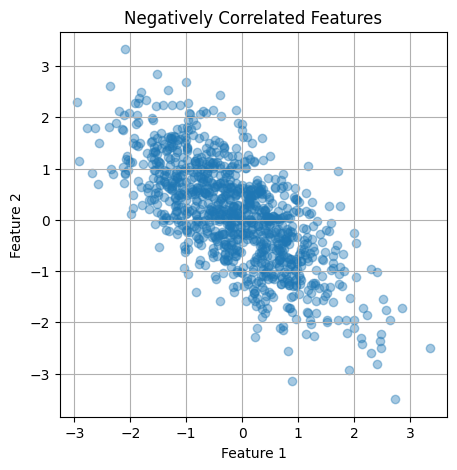

In [ ]:
Sigma = np.array([[1.0, -0.7],
                  [-0.7, 1.0]])

X_vis = np.random.multivariate_normal(
    mean=[0, 0],
    cov=Sigma,
    size=1000
)

plt.figure(figsize=(5,5))
plt.scatter(X_vis[:,0], X_vis[:,1], alpha=0.4)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Negatively Correlated Features")
plt.grid(True)
plt.show()


#MODULE 4

In [ ]:
def gradient_descent(X, t, lr=0.01, epochs=1000, lambda_l2=0.0, lambda_l1=0.0):
    n, d = X.shape
    w = np.zeros(d)
    for _ in range(epochs):
        error = X @ w - t

        grad = (2/n) * X.T @ error
        grad += 2 * lambda_l2 * w
        grad += lambda_l1 * np.sign(w)

        w -= lr * grad

    return w


In [ ]:
def ridge_closed_form(X, t, lambda_l2):
    d = X.shape[1]
    I = np.eye(d)
    return np.linalg.inv(X.T @ X + lambda_l2 * I) @ X.T @ t


In [ ]:
def inference(X, w):
    return X @ w


In [ ]:
def nrmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return rmse / (y_true.max() - y_true.min())

def nmae(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    return mae / (y_true.max() - y_true.min())


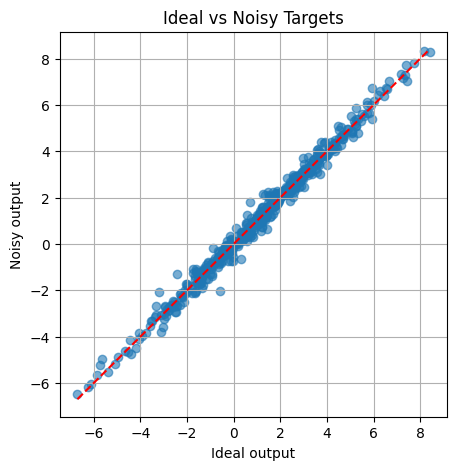

In [ ]:
# Problem setup
n = 500
cov = np.array([[1.0, -0.6],
                [-0.6, 1.0]])

w_true = np.array([1.0, 2.0, -1.0])  # bias + weights

X, t, t_ideal = generate_data(
    n=n,
    cov=cov,
    w=w_true,
    noise_type="laplacian",
    noise_param=0.2
)

plot_outputs(t_ideal, t)


In [ ]:
w_gd = gradient_descent(
    X, t,
    lr=0.01,
    epochs=2000,
    lambda_l2=0.1
)

w_ridge = ridge_closed_form(X, t, lambda_l2=0.1)


In [ ]:
pred_gd = inference(X, w_gd)
pred_ridge = inference(X, w_ridge)

print("GD NRMSE:", nrmse(t, pred_gd))
print("GD NMAE :", nmae(t, pred_gd))

print("Ridge NRMSE:", nrmse(t, pred_ridge))
print("Ridge NMAE :", nmae(t, pred_ridge))


GD NRMSE: 0.023820821583947202
GD NMAE : 0.01818979957805767
Ridge NRMSE: 0.019455439967814753
Ridge NMAE : 0.01411234172614685


# MODULE 5

In [ ]:
def gen_bv_data(n, noise="gaussian", scale=0.2):
    X = np.random.randn(n,1)
    X = np.hstack([np.ones((n,1)), X])
    w_true = np.array([1.0, 2.0])
    y_true = X @ w_true

    if noise == "gaussian":
        eps = np.random.normal(0, scale, n)
    else:
        eps = np.random.laplace(0, scale, n)

    return X, y_true + eps, y_true



In [ ]:
def fit_mse(X, y):
    return np.linalg.pinv(X) @ y

def fit_mae(X, y, lr=0.01, epochs=3000):
    w = np.zeros(X.shape[1])
    n = X.shape[0]

    for _ in range(epochs):
        grad = (1/n) * X.T @ np.sign(X @ w - y)
        w -= lr * grad

    return w


In [ ]:
def bias_variance(N, noise, estimator, R=100):
    Xtest, _, ytrue = gen_bv_data(2000, noise)
    preds = []

    for _ in range(R):
        Xtr, ytr, _ = gen_bv_data(N, noise)
        w = estimator(Xtr, ytr)
        preds.append(Xtest @ w)

    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)

    bias2 = np.mean((mean_pred - ytrue)**2)
    var = np.mean((preds - mean_pred)**2)
    return bias2, var


In [ ]:
Ns = [20, 50, 100, 300]
for N in Ns:
    _, var = bias_variance(
        N, "gaussian", fit_mse
    )
    print(f"N={N}, Variance={var:.4f}")


N=20, Variance=0.0038
N=50, Variance=0.0017
N=100, Variance=0.0009
N=300, Variance=0.0003


In [ ]:
print("\nTASK 2: Gaussian noise (MSE vs MAE)")

b_mse, v_mse = bias_variance(100, "gaussian", fit_mse)
b_mae, v_mae = bias_variance(100, "gaussian", fit_mae)

print(f"MSE → Bias²={b_mse:.5f}, Var={v_mse:.5f}, Total={b_mse+v_mse:.5f}")
print(f"MAE → Bias²={b_mae:.5f}, Var={v_mae:.5f}, Total={b_mae+v_mae:.5f}")




TASK 2: Gaussian noise (MSE vs MAE)
MSE → Bias²=0.00002, Var=0.00082, Total=0.00084
MAE → Bias²=0.00002, Var=0.00122, Total=0.00124


In [ ]:
print("\nTASK 3: Laplacian noise (MAE vs MSE)")

b_mse, v_mse = bias_variance(100, "laplacian", fit_mse)
b_mae, v_mae = bias_variance(100, "laplacian", fit_mae)

print(f"MSE → Bias²={b_mse:.5f}, Var={v_mse:.5f}, Total={b_mse+v_mse:.5f}")
print(f"MAE → Bias²={b_mae:.5f}, Var={v_mae:.5f}, Total={b_mae+v_mae:.5f}")



TASK 3: Laplacian noise (MAE vs MSE)
MSE → Bias²=0.00002, Var=0.00189, Total=0.00191
MAE → Bias²=0.00001, Var=0.00127, Total=0.00128


#MODULE6

In [ ]:
def correlated_data(n=200, rho=0.95):
    Sigma = [[1, rho], [rho, 1]]
    X = np.random.multivariate_normal([0,0], Sigma, n)
    X = np.hstack([np.ones((n,1)), X])
    w_true = np.array([1.0, 2.0, 2.0])
    y = X @ w_true + np.random.normal(0, 0.2, n)
    return X, y


In [ ]:
def ridge_fit(X, y, lam):
    d = X.shape[1]
    return np.linalg.inv(X.T @ X + lam*np.eye(d)) @ X.T @ y


In [ ]:
def lasso_fit(X, y, lam, lr=0.01, epochs=3000):
    w = np.zeros(X.shape[1])
    n = X.shape[0]

    for _ in range(epochs):
        grad = (2/n)*X.T@(X@w - y) + lam*np.sign(w)
        w -= lr*grad

    return w


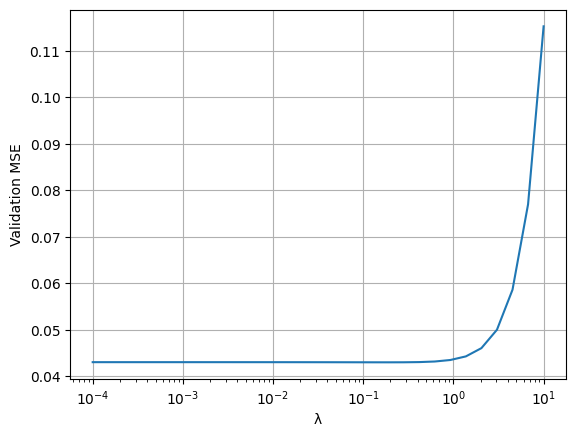

In [ ]:
X, y = correlated_data()
Xt, Xv = X[:100], X[100:]
yt, yv = y[:100], y[100:]

lams = np.logspace(-4, 1, 30)
errors = []

for lam in lams:
    w = ridge_fit(Xt, yt, lam)
    errors.append(np.mean((Xv @ w - yv)**2))

plt.semilogx(lams, errors)
plt.xlabel("λ")
plt.ylabel("Validation MSE")
plt.grid()
plt.show()


In [ ]:
for lam in [0.01, 0.1, 0.5]:
    w = lasso_fit(Xt, yt, lam)
    print(f"λ={lam} → weights={np.round(w,3)}")


λ=0.01 → weights=[0.996 2.082 1.908]
λ=0.1 → weights=[0.944 2.034 1.89 ]
λ=0.5 → weights=[0.711 1.823 1.81 ]


In [ ]:
print("No regularization:", np.round(ridge_fit(Xt, yt, 0), 3))
print("With L2:", np.round(ridge_fit(Xt, yt, 0.5), 3))


No regularization: [1.002 2.095 1.903]
With L2: [0.995 2.076 1.908]
